# <span style="color:#36a8ff; font-weight:bold;">🏥 Medical Insurance Cost Prediction using Machine Learning</span>

### Predicting healthcare insurance charges using demographic and lifestyle factors

**Author:** Shivam Kumar  
<span style="color:#ff4d4d;">
🔗 LinkedIn: https://www.linkedin.com/in/itshivam96  
🔗 GitHub: https://github.com/itshivam96
</span>

**Tools Used:** Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-Learn

**Machine Learning Models:**
- Linear Regression
- Random Forest Regressor

## 1. Business Problem

Insurance companies need accurate methods to estimate future medical expenses of customers.

Incorrect estimations can result in:

- Financial losses  
- Poor premium pricing  
- Risk management issues  

The objective of this project is to build a machine learning model capable of predicting individual insurance charges based on customer demographics and health-related attributes.

## 2. Project Workflow

Data Collection  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Data Understanding  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Data Cleaning  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Feature Engineering  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Exploratory Data Analysis  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Model Building  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Model Evaluation  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓  
Business Insights

## 3. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

import joblib

plt.style.use('seaborn-v0_8')

## 4. Load Dataset

### Objective
Load the insurance dataset and verify successful import.

In [2]:
data = pd.read_csv('insurance.csv')

## Dataset Preview

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Insight
The dataset contains demographic and lifestyle information that can influence healthcare costs.

## 5. Dataset Shape

In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 1338
Columns: 7


## Insight
- Total observations represent customers.  
- Total features represent predictive variables.  

Understanding dataset size helps estimate model complexity and training requirements.

## 6. Data Types Inspection

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Insight

I identify:

#### Numerical Features
- Age  
- BMI  
- Children  
- Charges  
#### Categorical Features
- Sex  
- Smoker  
- Region  

These categorical variables must be converted into machine-readable format.

## 7. Missing Value Analysis

In [6]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Insight

No missing values were detected.

This indicates the dataset is clean and ready for preprocessing.

## 8. Statistical Summary

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Key Observations

#### Age
- Wide distribution  
- Covers young and older adults  

#### BMI
- Several customers show elevated BMI levels  

#### Charges
- Significant variation  
- Presence of high-cost outliers  

This suggests healthcare expenses are not uniformly distributed.

## 9. Feature Engineering

In [8]:
# Encoding Binary Variables
data['sex'] = data['sex'].map({
    'male': 1,
    'female': 0
})

data['smoker'] = data['smoker'].map({
    'yes': 1,
    'no': 0
})

# One Hot Encoding Region
data = pd.get_dummies(
    data,
    columns=['region'],
    drop_first=True
)

## Why?

Machine learning algorithms require numerical inputs.

Encoding transforms categorical information into mathematical representation without losing information.

## 10. Exploratory Data Analysis

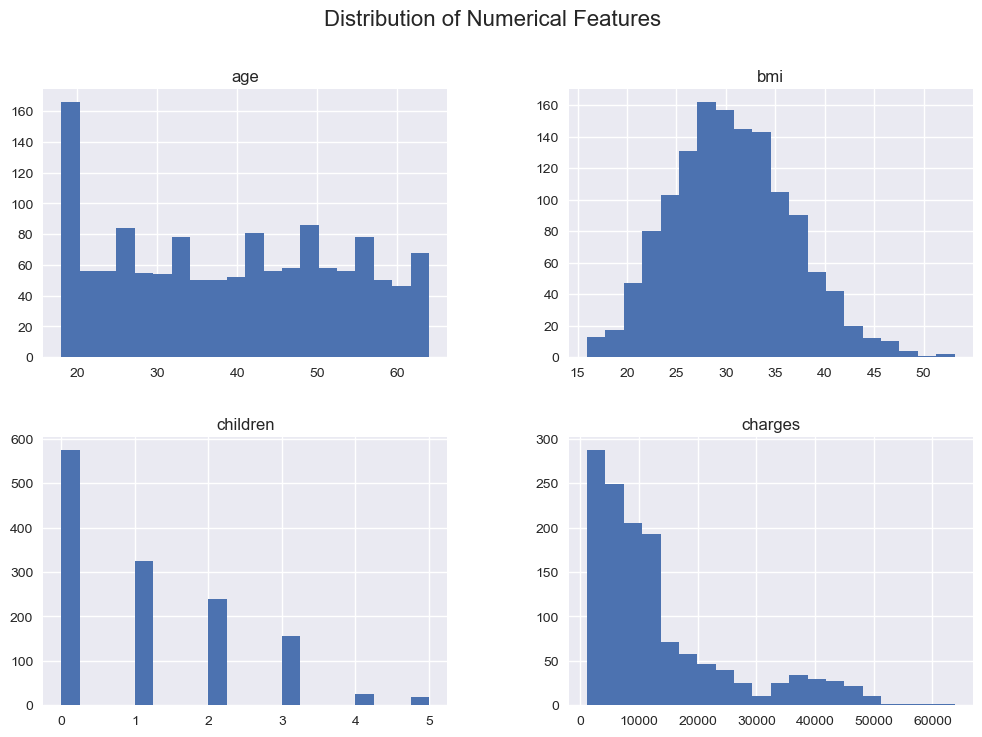

In [9]:
# Distribution Analysis
data[['age', 'bmi', 'children', 'charges']].hist(
    bins=20,
    figsize=(12, 8)
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.show()

## Insight

#### Charges
- Highly right-skewed  
- A small group of customers incur exceptionally high medical expenses  

#### BMI
- Near-normal distribution  

#### Age
- Reasonably balanced across age groups

## 11. Charges by Smoking Status

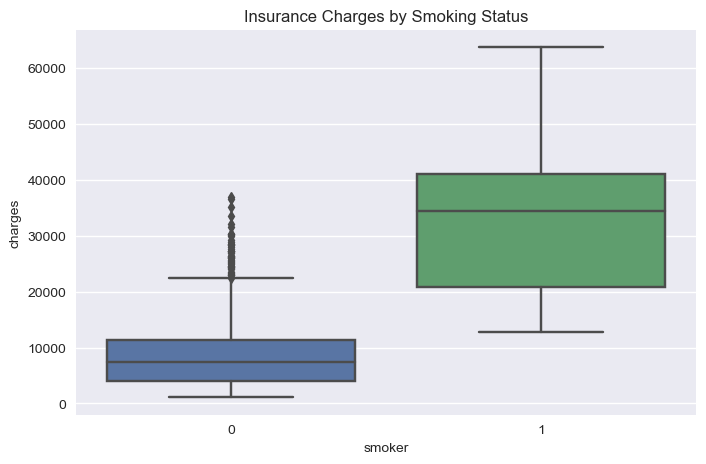

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=data
)

plt.title('Insurance Charges by Smoking Status')

plt.show()

## Business Insight

Smoking is the strongest visible driver of insurance costs.

Smokers incur substantially higher healthcare expenses compared to non-smokers.

This information can directly support premium pricing strategies.

## 12. Charges by Gender

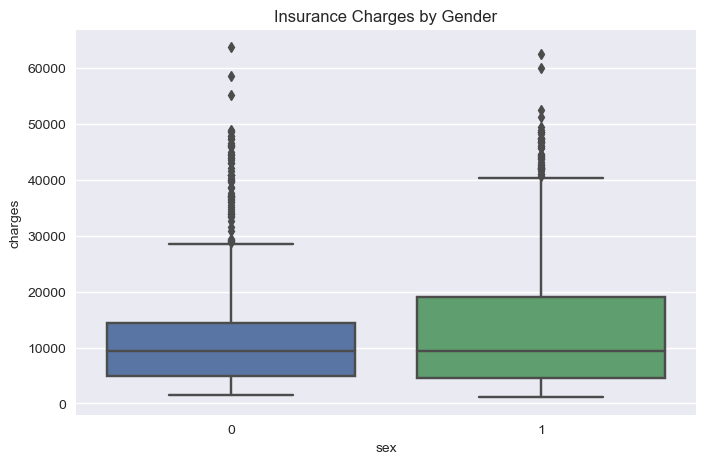

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='sex',
    y='charges',
    data=data
)

plt.title('Insurance Charges by Gender')

plt.show()

## Insight

Gender has relatively limited influence on insurance charges compared to smoking behavior.

## 13. Correlation Analysis

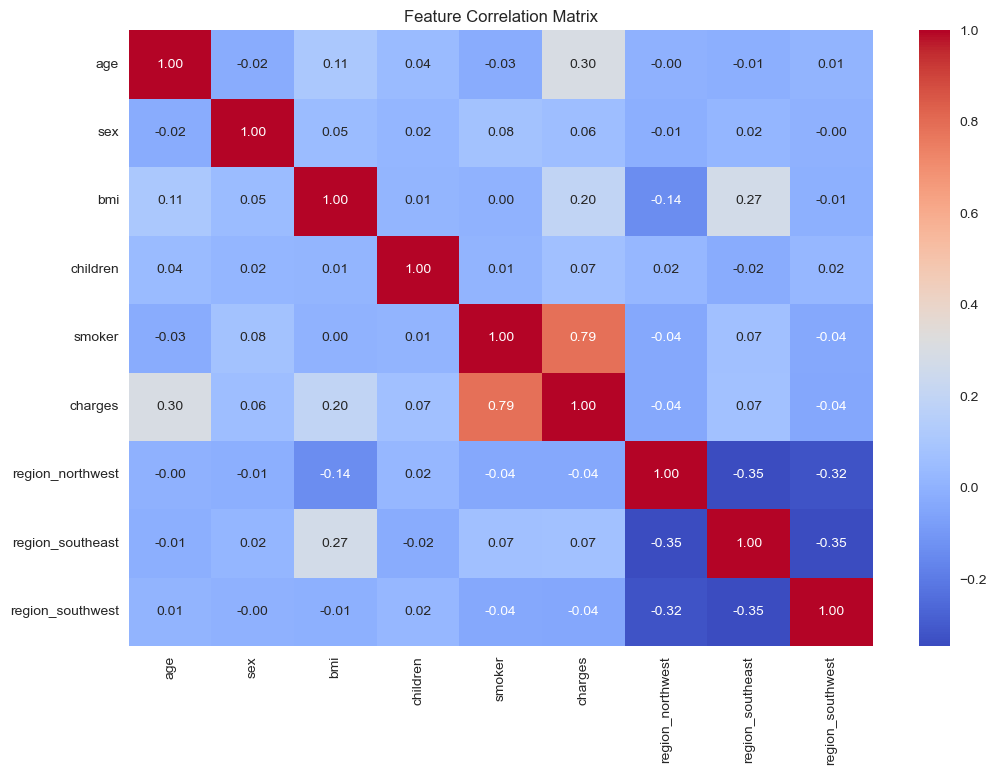

In [12]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

## Key Findings

#### Strongest positive correlations:
- Smoker → Charges  
- Age → Charges  

#### Weak correlations:
- Region variables  
- Gender  

This suggests smoking status and age are major predictive features.

## 14. Train-Test Split

In [13]:
X = data.drop('charges', axis=1)

y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 15. Model 1 — Linear Regression

## Why Linear Regression?

- Acts as a baseline model  
- Simple, interpretable, and widely used in insurance analytics  

In [14]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

In [15]:
lr_rmse = mean_squared_error(
    y_test,
    lr_pred,
    squared=False
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("RMSE :", lr_rmse)
print("R² :", lr_r2)

RMSE : 5796.2846592762735
R² : 0.7835929767120723


## Interpretation

R² explains how much variance in insurance charges is captured by the model.

Higher R² indicates stronger predictive capability.

## 16. Model 2 — Random Forest Regressor

## Why Random Forest?

Healthcare expenses often involve nonlinear relationships.

Random Forest captures complex patterns better than linear models.

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [17]:
rf_rmse = mean_squared_error(
    y_test,
    rf_pred,
    squared=False
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("RMSE :", rf_rmse)
print("R² :", rf_r2)

RMSE : 4588.326264493194
R² : 0.8643934948315269


## 17. Model Comparison Dashboard

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,5796.284659,0.783593
1,Random Forest,4588.326264,0.864393


## Business Conclusion

The model with:

- Lower RMSE  
- Higher R²  

will be selected for deployment.

## 18. Feature Importance Analysis

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker,0.609377
2,bmi,0.214740
0,age,0.134716
3,children,0.019588
1,sex,0.006323
5,region_northwest,0.005764
6,region_southeast,0.005410
7,region_southwest,0.004083


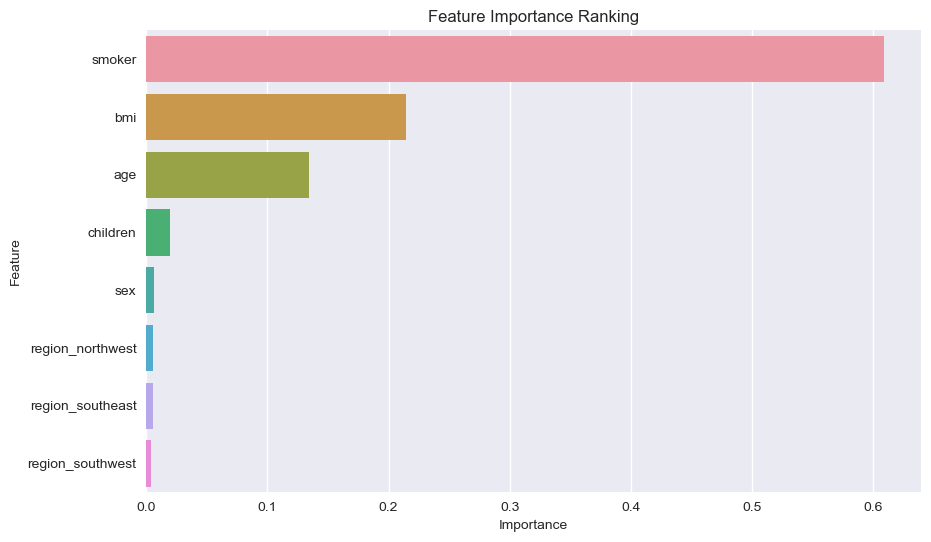

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance Ranking')

plt.show()

## Key Business Drivers

Expected top features:

- Smoker Status  
- Age  
- BMI  

These variables contribute most to healthcare cost prediction.

## 19. Prediction Performance Visualization

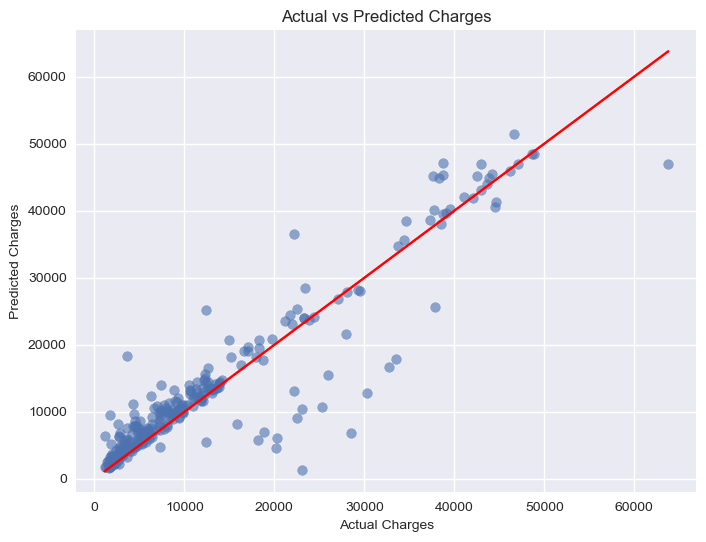

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

## Interpretation

Points closer to the diagonal line indicate better prediction accuracy.

## 20. Save Final Model

In [22]:
joblib.dump(
    rf_model,
    'random_forest_model.pkl'
)

['random_forest_model.pkl']

## 21. Final Business Recommendations

Insurance Companies Should:

- ✅ Monitor smoker profiles carefully  
- ✅ Use age and BMI as major premium indicators  
- ✅ Build personalized premium strategies  
- ✅ Deploy machine learning-based pricing systems  

## 22. Future Improvements

- XGBoost  
- LightGBM  
- Hyperparameter Tuning  
- Feature Scaling  
- Cross Validation  
- SHAP Explainability  
- Model Deployment using Streamlit  

## 🎯 Final Result

#### Best Model
Random Forest Regressor  

#### Key Predictors
- Smoking Status  
- Age  
- BMI  

#### Business Value
Accurate insurance charge prediction enables:

- Better premium pricing  
- Reduced financial risk  
- Improved customer segmentation  